# Induction Head Ablation Study

Run ablation experiments on candidate induction heads identified in notebook 05.

Tests whether heads that are nearby known GPT-2 induction heads in embedding space
also behave like induction heads when ablated.

## Metrics:
1. **Loss on repeated sequences** - core induction test
2. **Prefix matching score** - attention pattern analysis
3. **In-context learning score** - early vs late loss

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import numpy as np
import torch

# attention-motifs ablation
from attention_motifs.ablation import (
    AblationMethod,
    HeadAblator,
    CandidateHeads,
    find_candidate_induction_heads,
    get_control_heads,
    generate_repeated_sequences,
    repeated_sequence_loss,
    prefix_matching_score,
    icl_score,
    run_ablation_experiment,
)
from attention_motifs.ablation.experiment import (
    ExperimentConfig,
    ExperimentResults,
    analyze_results,
    identify_induction_heads,
)
from attention_motifs.ablation.candidates import load_candidates_from_file
from attention_motifs.ablation.ablate import heads_from_strings
from attention_motifs.features.analysis import DistanceTensorResult

from transformer_lens import HookedTransformer

In [2]:
# config
pl.Config.set_tbl_rows(30)
PATH_BASE: Path = Path("../data/")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


# Load candidates from notebook 05

In [3]:
# load candidates (or regenerate if needed)
candidates_path = PATH_BASE / "ablation" / "candidates.json"

if candidates_path.exists():
    CANDIDATES = load_candidates_from_file(candidates_path)
    print(f"Loaded {len(CANDIDATES.candidates_by_model)} models worth of candidates")
else:
    print("Candidates not found, regenerating...")
    HEAD_DISTS = DistanceTensorResult.read_raw(PATH_BASE / "features" / "head_dists_raw")
    CANDIDATES = find_candidate_induction_heads(HEAD_DISTS, k_neighbors=20)

Loaded 5 models worth of candidates


In [4]:
# show available models
for model, candidates in CANDIDATES.candidates_by_model.items():
    print(f"{model}: {len(candidates)} candidates")

gpt2-medium: 37 candidates
gemma-2-2b: 7 candidates
Llama-3-2-1B: 33 candidates
pythia-1b: 12 candidates
gemma-2b: 3 candidates


# Sanity check: Verify ablation works on known GPT-2 induction heads

In [5]:
# load gpt2-small and test known induction heads
model_gpt2 = HookedTransformer.from_pretrained("gpt2-small", device=DEVICE)

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer


In [6]:
# generate test sequences
sequences = generate_repeated_sequences(
    tokenizer=model_gpt2.tokenizer,
    n_sequences=50,
    seq_length=25,
    n_repetitions=4,
    seed=42,
    device=DEVICE,
)
print(f"Generated {len(sequences)} test sequences")

Generated 50 test sequences


In [7]:
# baseline loss (no ablation)
baseline_loss = repeated_sequence_loss(model_gpt2, sequences)
print(f"Baseline loss on repeated sequences: {baseline_loss:.4f}")

Baseline loss on repeated sequences: 0.2510


In [8]:
# test ablating known induction heads
KNOWN_INDUCTION_HEADS = [(5, 5), (6, 9), (5, 8), (5, 9)]  # from IOI paper

ablator = HeadAblator(model_gpt2)

# compute mean activations for mean ablation
calibration_tokens = [s.tokens for s in sequences[:30]]
ablator.compute_mean_activations(calibration_tokens)

print("\nZero Ablation Results:")
print("-" * 50)
for layer, head in KNOWN_INDUCTION_HEADS:
    with ablator.ablate_heads([(layer, head)], AblationMethod.ZERO):
        ablated_loss = repeated_sequence_loss(model_gpt2, sequences)
    loss_increase = ablated_loss - baseline_loss
    prefix = prefix_matching_score(model_gpt2, layer, head, sequences)
    print(f"L{layer}:H{head}: loss={ablated_loss:.4f} (increase={loss_increase:.4f}), prefix={prefix:.4f}")

Computing mean activations: 100%|██████████| 4/4 [00:01<00:00,  2.77it/s]



Zero Ablation Results:
--------------------------------------------------
L5:H5: loss=0.3504 (increase=0.0994), prefix=0.0014
L6:H9: loss=0.4278 (increase=0.1768), prefix=0.0006
L5:H8: loss=0.5161 (increase=0.2652), prefix=0.0106
L5:H9: loss=0.4862 (increase=0.2352), prefix=0.0195


In [9]:
# compare to ablating non-induction heads
NON_INDUCTION_HEADS = [(0, 0), (1, 1), (2, 2), (11, 11)]  # random heads

print("\nNon-Induction Heads (control):")
print("-" * 50)
for layer, head in NON_INDUCTION_HEADS:
    with ablator.ablate_heads([(layer, head)], AblationMethod.ZERO):
        ablated_loss = repeated_sequence_loss(model_gpt2, sequences)
    loss_increase = ablated_loss - baseline_loss
    prefix = prefix_matching_score(model_gpt2, layer, head, sequences)
    print(f"L{layer}:H{head}: loss={ablated_loss:.4f} (increase={loss_increase:.4f}), prefix={prefix:.4f}")


Non-Induction Heads (control):
--------------------------------------------------
L0:H0: loss=0.4506 (increase=0.1997), prefix=0.0163
L1:H1: loss=0.4890 (increase=0.2381), prefix=0.0011
L2:H2: loss=0.5205 (increase=0.2696), prefix=0.0010
L11:H11: loss=0.5388 (increase=0.2879), prefix=0.0126


# Run full experiment on candidate model

In [10]:
# select model to test (change this to test different models)
TARGET_MODEL = "pythia-1b"  # or "gemma-2b", etc.

# get candidates and controls
model_candidates = CANDIDATES.get_top_candidates(TARGET_MODEL, n=10)
print(f"Top 10 candidates for {TARGET_MODEL}:")
for head, score in model_candidates:
    print(f"  {head}: {score:.3f}")

Top 10 candidates for pythia-1b:
  pythia-1b:L7:H1: 1.700
  pythia-1b:L5:H7: 0.850
  pythia-1b:L4:H4: 0.800
  pythia-1b:L7:H2: 0.750
  pythia-1b:L5:H4: 0.600
  pythia-1b:L7:H0: 0.550
  pythia-1b:L6:H2: 0.450
  pythia-1b:L11:H7: 0.400
  pythia-1b:L10:H6: 0.400
  pythia-1b:L9:H4: 0.200


In [11]:
# run experiment
config = ExperimentConfig(
    n_sequences=100,
    seq_length=25,
    n_repetitions=4,
    ablation_methods=[AblationMethod.ZERO, AblationMethod.MEAN],
    seed=42,
)

candidate_heads = [h for h, _ in model_candidates]

# get control heads from distance matrix
HEAD_DISTS = DistanceTensorResult.read_raw(PATH_BASE / "features" / "head_dists_raw")
control_heads = get_control_heads(HEAD_DISTS, CANDIDATES, TARGET_MODEL, n_controls=5, method="far")

print(f"\nControl heads: {control_heads}")


Control heads: ['pythia-1b:L3:H5', 'pythia-1b:L0:H1', 'pythia-1b:L0:H5', 'pythia-1b:L0:H4', 'pythia-1b:L0:H3']


In [12]:
# run the experiment
results = run_ablation_experiment(
    model_name=TARGET_MODEL,
    candidate_heads=candidate_heads,
    control_heads=control_heads,
    config=config,
    device=DEVICE,
)

Loading model: pythia-1b
Loaded pretrained model pythia-1b into HookedTransformer
Generating test sequences...
Computing mean activations for calibration...


Computing mean activations: 100%|██████████| 7/7 [00:11<00:00,  1.68s/it]


Computing baseline metrics...


Ablating heads: 100%|██████████| 15/15 [23:53<00:00, 95.58s/it]


In [13]:
# view results
results_df = results.to_dataframe()
results_df.sort("loss_increase", descending=True)

head,ablation_method,baseline_repeated_loss,ablated_repeated_loss,loss_increase,baseline_prefix_score,ablated_prefix_score,prefix_score_decrease,baseline_icl_score,ablated_icl_score,icl_degradation
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""pythia-1b:L0:H3""","""mean""",0.397016,8.867834,8.470819,0.007717,0.007717,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H3""","""zero""",0.397016,8.867408,8.470392,0.007717,0.007717,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H4""","""mean""",0.397016,8.390784,7.993769,0.013152,0.013152,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H4""","""zero""",0.397016,8.324787,7.927772,0.013152,0.013152,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H5""","""zero""",0.397016,7.193345,6.796329,0.010551,0.010551,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H5""","""mean""",0.397016,7.097943,6.700928,0.010551,0.010551,0.0,0.0,0.0,0.0
"""pythia-1b:L3:H5""","""zero""",0.397016,6.345839,5.948823,4.6070e-8,4.6070e-8,0.0,0.0,0.0,0.0
"""pythia-1b:L3:H5""","""mean""",0.397016,5.951847,5.554831,4.6070e-8,4.6070e-8,0.0,0.0,0.0,0.0
"""pythia-1b:L0:H1""","""zero""",0.397016,5.944387,5.547371,0.010235,0.010235,0.0,0.0,0.0,0.0


# Analyze and visualize results

In [14]:
# summary statistics
summary = analyze_results(results)
summary

head,mean_loss_increase,max_loss_increase,mean_prefix_decrease,mean_icl_degradation
str,f64,f64,f64,f64
"""pythia-1b:L0:H3""",8.470605,8.470819,0.0,0.0
"""pythia-1b:L0:H4""",7.96077,7.993769,0.0,0.0
"""pythia-1b:L0:H5""",6.748628,6.796329,0.0,0.0
"""pythia-1b:L3:H5""",5.751827,5.948823,0.0,0.0
"""pythia-1b:L0:H1""",5.540334,5.547371,0.0,0.0
"""pythia-1b:L10:H6""",4.027112,4.061077,0.0,0.0
"""pythia-1b:L9:H4""",3.911668,3.916885,0.0,0.0
"""pythia-1b:L11:H7""",3.370912,3.403775,0.0,0.0
"""pythia-1b:L6:H2""",3.329227,3.560527,0.0,0.0


/tmp/ipykernel_1059688/2095409036.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([candidate_losses, control_losses], labels=["Candidates", "Controls"])
/tmp/ipykernel_1059688/2095409036.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([candidate_prefix, control_prefix], labels=["Candidates", "Controls"])


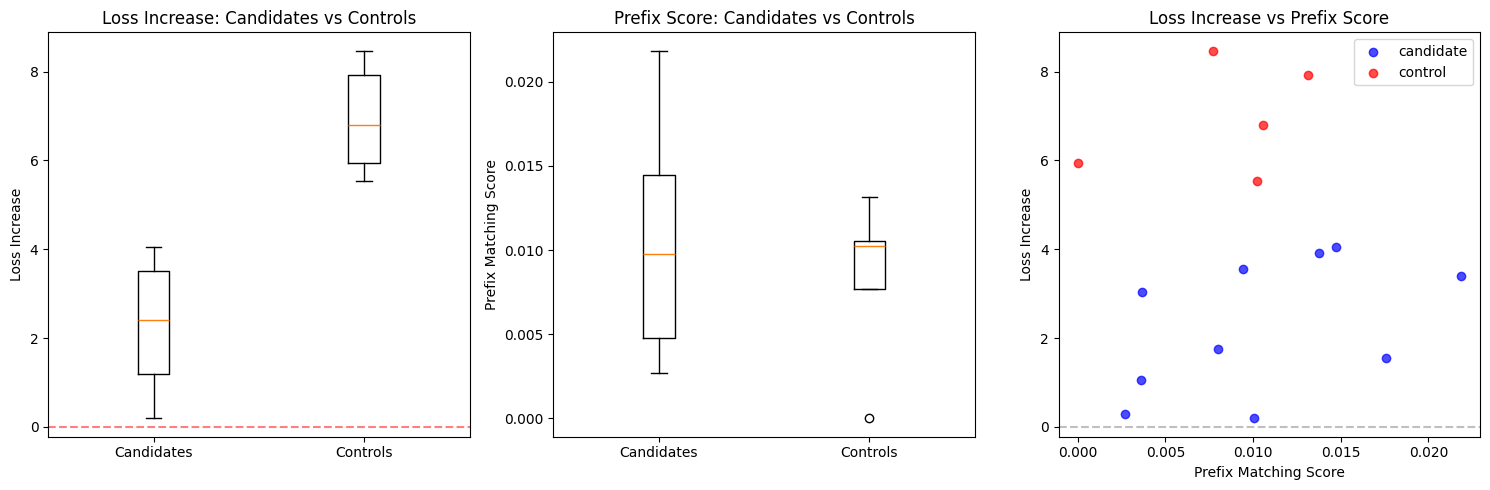

In [15]:
# plot loss increase for candidates vs controls
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# separate candidates and controls
candidate_set = set(candidate_heads)
control_set = set(control_heads)

df_zero = results_df.filter(pl.col("ablation_method") == "zero")

# mark as candidate or control
df_zero = df_zero.with_columns(
    pl.when(pl.col("head").is_in(candidate_set))
    .then(pl.lit("candidate"))
    .otherwise(pl.lit("control"))
    .alias("type")
)

# plot 1: loss increase comparison
candidate_losses = df_zero.filter(pl.col("type") == "candidate")["loss_increase"].to_numpy()
control_losses = df_zero.filter(pl.col("type") == "control")["loss_increase"].to_numpy()

axes[0].boxplot([candidate_losses, control_losses], labels=["Candidates", "Controls"])
axes[0].set_ylabel("Loss Increase")
axes[0].set_title("Loss Increase: Candidates vs Controls")
axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# plot 2: prefix score
candidate_prefix = df_zero.filter(pl.col("type") == "candidate")["baseline_prefix_score"].to_numpy()
control_prefix = df_zero.filter(pl.col("type") == "control")["baseline_prefix_score"].to_numpy()

axes[1].boxplot([candidate_prefix, control_prefix], labels=["Candidates", "Controls"])
axes[1].set_ylabel("Prefix Matching Score")
axes[1].set_title("Prefix Score: Candidates vs Controls")

# plot 3: scatter of loss increase vs prefix score
for type_name, color in [("candidate", "blue"), ("control", "red")]:
    subset = df_zero.filter(pl.col("type") == type_name)
    axes[2].scatter(
        subset["baseline_prefix_score"].to_numpy(),
        subset["loss_increase"].to_numpy(),
        label=type_name,
        alpha=0.7,
        c=color,
    )

axes[2].set_xlabel("Prefix Matching Score")
axes[2].set_ylabel("Loss Increase")
axes[2].set_title("Loss Increase vs Prefix Score")
axes[2].legend()
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig(f"figures/ablation_results_{TARGET_MODEL.replace('/', '_')}.pdf", bbox_inches="tight")

In [16]:
# identify which candidates are likely induction heads
induction_heads = identify_induction_heads(
    results,
    loss_threshold=0.3,
    prefix_threshold=0.05,
)

print(f"\nHeads classified as likely induction heads ({len(induction_heads)}):")
for head in induction_heads:
    print(f"  {head}")


Heads classified as likely induction heads (0):


# Save results

In [17]:
# save results
output_dir = PATH_BASE / "ablation"
output_dir.mkdir(parents=True, exist_ok=True)

results.save(output_dir / f"{TARGET_MODEL.replace('/', '_')}_results.json")
results_df.write_csv(output_dir / f"{TARGET_MODEL.replace('/', '_')}_results.csv")

print(f"Results saved to {output_dir}")

Results saved to ../data/ablation


# Compare zero vs mean ablation

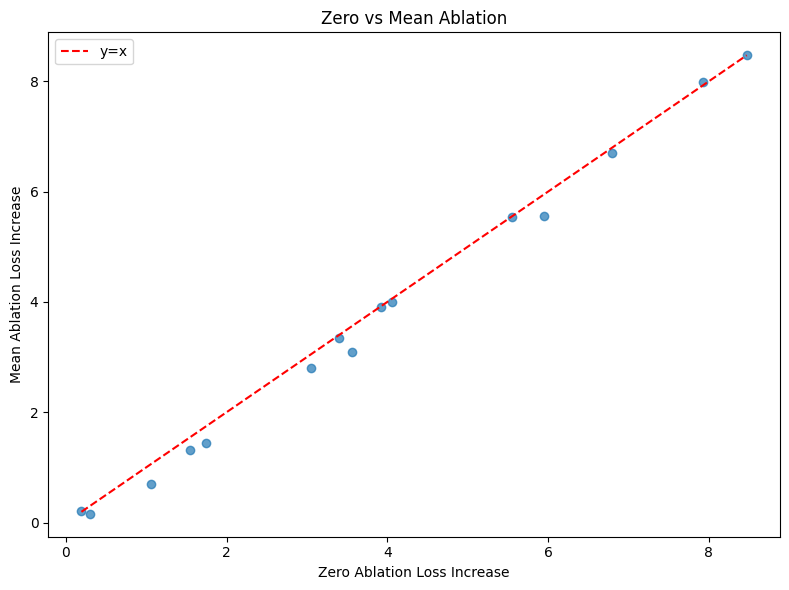

In [18]:
# compare ablation methods
fig, ax = plt.subplots(figsize=(8, 6))

zero_losses = results_df.filter(pl.col("ablation_method") == "zero")["loss_increase"].to_numpy()
mean_losses = results_df.filter(pl.col("ablation_method") == "mean")["loss_increase"].to_numpy()

ax.scatter(zero_losses, mean_losses, alpha=0.7)
ax.plot([min(zero_losses), max(zero_losses)], [min(zero_losses), max(zero_losses)], 'r--', label='y=x')
ax.set_xlabel("Zero Ablation Loss Increase")
ax.set_ylabel("Mean Ablation Loss Increase")
ax.set_title("Zero vs Mean Ablation")
ax.legend()

plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig(f"figures/ablation_methods_{TARGET_MODEL.replace('/', '_')}.pdf", bbox_inches="tight")